# 02. Rate and Credit Regime Analysis

This notebook constructs the pre-specified fixed-income market regimes used for subsequent portfolio positioning.

## Primary Signals

- **Rate signal:** 3-month change in the U.S. 10-year Treasury yield
- **Credit signal:** 3-month change in the Moody's Baa corporate spread relative to the 10-year Treasury

The signals are defined before portfolio performance is evaluated.

No portfolio weights are selected in this notebook.

In [2]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "figures"

print("Current directory :", CURRENT_DIR)
print("Project root      :", PROJECT_ROOT)
print("Processed dir     :", PROCESSED_DIR)

Current directory : c:\Users\minha\Desktop\global-fixed-income-strategy\notebooks
Project root      : c:\Users\minha\Desktop\global-fixed-income-strategy
Processed dir     : c:\Users\minha\Desktop\global-fixed-income-strategy\data\processed


In [4]:
PANEL_PATH = (
    PROCESSED_DIR
    / "fixed_income_monthly_panel.csv"
)

monthly_panel = pd.read_csv(
    PANEL_PATH,
    index_col="Date",
    parse_dates=True,
)

monthly_panel.index.name = "Date"

print("Shape:", monthly_panel.shape)
print(
    "Date range:",
    monthly_panel.index.min(),
    "to",
    monthly_panel.index.max(),
)

monthly_panel.head()

Shape: (223, 24)
Date range: 2008-01-31 00:00:00 to 2026-07-31 00:00:00


,US2Y,US5Y,US10Y,US30Y,2s10s_bps,5s30s_bps,BAA10Y,BAA10Y_bps,US10Y_obs_date,BAA10Y_obs_date,...,LQD_price,HYG_price,SHY_ret,IEF_ret,TLT_ret,LQD_ret,HYG_ret,US10Y_obs_lag_days,BAA10Y_obs_lag_days,ETF_obs_lag_days
Date,,,,,,,,,,,,,,,,,,,,,
2008-01-31,2.17,2.82,3.67,4.35,150.0,153.0,2.96,296.0,2008-01-31,2008-01-31,...,52.342274,31.324257,NaN,NaN,NaN,NaN,NaN,0,0,0
2008-02-29,1.65,2.50,3.53,4.41,188.0,191.0,3.22,322.0,2008-02-29,2008-02-29,...,51.972607,30.738672,0.010332,0.012392,-0.004553,-0.007062,-0.018694,0,0,0
2008-03-31,1.62,2.46,3.45,4.30,183.0,184.0,3.45,345.0,2008-03-31,2008-03-31,...,51.662254,31.029505,0.002535,0.013373,0.021388,-0.005971,0.009461,0,0,0
2008-04-30,2.29,3.03,3.77,4.49,148.0,146.0,3.10,310.0,2008-04-30,2008-04-30,...,52.305233,32.083557,-0.008375,-0.024174,-0.024862,0.012446,0.033969,0,0,0
2008-05-31,2.66,3.41,4.06,4.72,140.0,131.0,3.00,300.0,2008-05-30,2008-05-30,...,51.151871,31.920414,-0.003461,-0.017775,-0.026883,-0.022051,-0.005085,1,1,1


In [5]:
required_columns = [
    "US10Y",
    "BAA10Y",
    "BAA10Y_bps",
    "2s10s_bps",
    "5s30s_bps",
]

missing_columns = [
    col
    for col in required_columns
    if col not in monthly_panel.columns
]

assert len(missing_columns) == 0, (
    f"Missing required columns: {missing_columns}"
)

print("Required regime inputs are available.")

Required regime inputs are available.


## 1. Pre-Specified Three-Month Signals

The rate and credit signals use simple three-month changes.

No threshold is estimated from subsequent ETF performance.

A positive change indicates:

- **US10Y:** rising Treasury yields
- **BAA10Y:** widening credit spreads

A negative change indicates:

- **US10Y:** falling Treasury yields
- **BAA10Y:** tightening credit spreads

In [6]:
regime_data = monthly_panel.copy()

regime_data["US10Y_3m_change_bps"] = (
    regime_data["US10Y"]
    - regime_data["US10Y"].shift(3)
) * 100

regime_data["BAA10Y_3m_change_bps"] = (
    regime_data["BAA10Y"]
    - regime_data["BAA10Y"].shift(3)
) * 100

regime_data[
    [
        "US10Y",
        "US10Y_3m_change_bps",
        "BAA10Y_bps",
        "BAA10Y_3m_change_bps",
    ]
].head(10)

,US10Y,US10Y_3m_change_bps,BAA10Y_bps,BAA10Y_3m_change_bps
Date,,,,
2008-01-31,3.67,NaN,296.0,NaN
2008-02-29,3.53,NaN,322.0,NaN
2008-03-31,3.45,NaN,345.0,NaN
2008-04-30,3.77,10.0,310.0,14.0
2008-05-31,4.06,53.0,300.0,-22.0
2008-06-30,3.99,54.0,305.0,-40.0
2008-07-31,3.99,22.0,322.0,12.0
2008-08-31,3.83,-23.0,329.0,29.0
2008-09-30,3.85,-14.0,400.0,95.0


In [7]:
check_date = regime_data.index[-1]
lag_date = regime_data.index[-4]

current_us10y = regime_data.loc[
    check_date, "US10Y"
]

lagged_us10y = regime_data.loc[
    lag_date, "US10Y"
]

manual_rate_change = (
    current_us10y - lagged_us10y
) * 100

stored_rate_change = regime_data.loc[
    check_date,
    "US10Y_3m_change_bps",
]

current_baa = regime_data.loc[
    check_date, "BAA10Y"
]

lagged_baa = regime_data.loc[
    lag_date, "BAA10Y"
]

manual_credit_change = (
    current_baa - lagged_baa
) * 100

stored_credit_change = regime_data.loc[
    check_date,
    "BAA10Y_3m_change_bps",
]

print("Current month:", check_date)
print("3M comparison month:", lag_date)

print("\nRate signal")
print("Stored :", stored_rate_change)
print("Manual :", manual_rate_change)

print("\nCredit signal")
print("Stored :", stored_credit_change)
print("Manual :", manual_credit_change)

assert np.isclose(
    stored_rate_change,
    manual_rate_change
)

assert np.isclose(
    stored_credit_change,
    manual_credit_change
)

print("\n3M signal calculation passed.")

Current month: 2026-07-31 00:00:00
3M comparison month: 2026-04-30 00:00:00

Rate signal
Stored : 34.999999999999964
Manual : 34.999999999999964

Credit signal
Stored : -7.000000000000006
Manual : -7.000000000000006

3M signal calculation passed.


In [8]:
rate_zero_count = (
    regime_data["US10Y_3m_change_bps"]
    .dropna()
    .eq(0)
    .sum()
)

credit_zero_count = (
    regime_data["BAA10Y_3m_change_bps"]
    .dropna()
    .eq(0)
    .sum()
)

print(
    "Exact 0bp rate changes:",
    rate_zero_count
)

print(
    "Exact 0bp credit-spread changes:",
    credit_zero_count
)

Exact 0bp rate changes: 3
Exact 0bp credit-spread changes: 2


In [9]:
def classify_rate_state(x):
    if pd.isna(x):
        return np.nan
    elif x > 0:
        return "Rising"
    elif x < 0:
        return "Falling"
    else:
        return "Stable"


def classify_credit_state(x):
    if pd.isna(x):
        return np.nan
    elif x > 0:
        return "Widening"
    elif x < 0:
        return "Tightening"
    else:
        return "Stable"

In [10]:
regime_data["Rate_State"] = (
    regime_data["US10Y_3m_change_bps"]
    .apply(classify_rate_state)
)

regime_data["Credit_State"] = (
    regime_data["BAA10Y_3m_change_bps"]
    .apply(classify_credit_state)
)

regime_data[
    [
        "US10Y_3m_change_bps",
        "Rate_State",
        "BAA10Y_3m_change_bps",
        "Credit_State",
    ]
].tail(12)

,US10Y_3m_change_bps,Rate_State,BAA10Y_3m_change_bps,Credit_State
Date,,,,
2025-08-31,-18.0,Falling,-4.0,Tightening
2025-09-30,-8.0,Falling,-8.0,Tightening
2025-10-31,-26.0,Falling,2.0,Widening
2025-11-30,-21.0,Falling,-2.0,Tightening
2025-12-31,2.0,Rising,5.0,Widening
2026-01-31,15.0,Rising,-7.0,Tightening
2026-02-28,-5.0,Falling,2.0,Widening
2026-03-31,12.0,Rising,7.0,Widening
2026-04-30,14.0,Rising,8.0,Widening


## 2. Four Rate-Credit Regimes

The two primary market dimensions are combined into four economically interpretable regimes.

| Rate State | Credit State | Regime |
|---|---|---|
| Falling | Tightening | Falling / Tightening |
| Falling | Widening | Falling / Widening |
| Rising | Tightening | Rising / Tightening |
| Rising | Widening | Rising / Widening |

Observations classified as Stable on either dimension are retained separately rather than forced into one of the four primary regimes.

In [11]:
def classify_regime(row):
    rate_state = row["Rate_State"]
    credit_state = row["Credit_State"]

    if pd.isna(rate_state) or pd.isna(credit_state):
        return np.nan

    if (
        rate_state == "Stable"
        or credit_state == "Stable"
    ):
        return "Stable / Mixed"

    return (
        f"{rate_state} / {credit_state}"
    )

In [12]:
regime_data["Regime"] = (
    regime_data.apply(
        classify_regime,
        axis=1,
    )
)

regime_data[
    [
        "US10Y_3m_change_bps",
        "BAA10Y_3m_change_bps",
        "Rate_State",
        "Credit_State",
        "Regime",
    ]
].tail(12)

,US10Y_3m_change_bps,BAA10Y_3m_change_bps,Rate_State,Credit_State,Regime
Date,,,,,
2025-08-31,-18.0,-4.0,Falling,Tightening,Falling / Tightening
2025-09-30,-8.0,-8.0,Falling,Tightening,Falling / Tightening
2025-10-31,-26.0,2.0,Falling,Widening,Falling / Widening
2025-11-30,-21.0,-2.0,Falling,Tightening,Falling / Tightening
2025-12-31,2.0,5.0,Rising,Widening,Rising / Widening
2026-01-31,15.0,-7.0,Rising,Tightening,Rising / Tightening
2026-02-28,-5.0,2.0,Falling,Widening,Falling / Widening
2026-03-31,12.0,7.0,Rising,Widening,Rising / Widening
2026-04-30,14.0,8.0,Rising,Widening,Rising / Widening


In [13]:
regime_counts = (
    regime_data["Regime"]
    .value_counts(dropna=False)
)

regime_counts

Regime
Rising / Tightening     83
Falling / Widening      57
Falling / Tightening    46
Rising / Widening       30
Stable / Mixed           4
NaN                      3
Name: count, dtype: int64

In [14]:
valid_regimes = (
    regime_data["Regime"]
    .dropna()
)

regime_distribution = pd.DataFrame({
    "Count": valid_regimes.value_counts(),
    "Share": (
        valid_regimes
        .value_counts(normalize=True)
    ),
})

regime_distribution

,Count,Share
Regime,,
Rising / Tightening,83,0.377273
Falling / Widening,57,0.259091
Falling / Tightening,46,0.209091
Rising / Widening,30,0.136364
Stable / Mixed,4,0.018182


In [15]:
regime_data.loc[
    "2008-04-30":"2009-12-31",
    [
        "US10Y_3m_change_bps",
        "BAA10Y_3m_change_bps",
        "Regime",
    ],
]

,US10Y_3m_change_bps,BAA10Y_3m_change_bps,Regime
Date,,,
2008-04-30,10.0,14.0,Rising / Widening
2008-05-31,53.0,-22.0,Rising / Tightening
2008-06-30,54.0,-40.0,Rising / Tightening
2008-07-31,22.0,12.0,Rising / Widening
2008-08-31,-23.0,29.0,Falling / Widening
2008-09-30,-14.0,95.0,Falling / Widening
2008-10-31,2.0,231.0,Rising / Widening
2008-11-30,-90.0,281.0,Falling / Widening
2008-12-31,-160.0,182.0,Falling / Widening


In [16]:
regime_data.loc[
    "2008-04-30":"2009-12-31",
    [
        "US10Y_3m_change_bps",
        "BAA10Y_3m_change_bps",
        "Regime",
    ],
]

,US10Y_3m_change_bps,BAA10Y_3m_change_bps,Regime
Date,,,
2008-04-30,10.0,14.0,Rising / Widening
2008-05-31,53.0,-22.0,Rising / Tightening
2008-06-30,54.0,-40.0,Rising / Tightening
2008-07-31,22.0,12.0,Rising / Widening
2008-08-31,-23.0,29.0,Falling / Widening
2008-09-30,-14.0,95.0,Falling / Widening
2008-10-31,2.0,231.0,Rising / Widening
2008-11-30,-90.0,281.0,Falling / Widening
2008-12-31,-160.0,182.0,Falling / Widening


In [17]:
regime_data.loc[
    "2019-10-31":"2020-12-31",
    [
        "US10Y",
        "US10Y_3m_change_bps",
        "BAA10Y_bps",
        "BAA10Y_3m_change_bps",
        "Regime",
    ],
]

,US10Y,US10Y_3m_change_bps,BAA10Y_bps,BAA10Y_3m_change_bps,Regime
Date,,,,,
2019-10-31,1.69,-33.0,218.0,5.0,Falling / Widening
2019-11-30,1.78,28.0,208.0,-18.0,Rising / Tightening
2019-12-31,1.92,24.0,198.0,-22.0,Rising / Tightening
2020-01-31,1.51,-18.0,213.0,-5.0,Falling / Tightening
2020-02-29,1.13,-65.0,238.0,30.0,Falling / Widening
2020-03-31,0.70,-122.0,393.0,195.0,Falling / Widening
2020-04-30,0.64,-87.0,323.0,110.0,Falling / Widening
2020-05-31,0.65,-48.0,308.0,70.0,Falling / Widening
2020-06-30,0.66,-4.0,293.0,-100.0,Falling / Tightening


In [18]:
regime_data.loc[
    "2021-07-31":"2023-06-30",
    [
        "US10Y",
        "US10Y_3m_change_bps",
        "BAA10Y_bps",
        "BAA10Y_3m_change_bps",
        "Regime",
    ],
]

,US10Y,US10Y_3m_change_bps,BAA10Y_bps,BAA10Y_3m_change_bps,Regime
Date,,,,,
2021-07-31,1.24,-41.0,195.0,-1.0,Falling / Tightening
2021-08-31,1.30,-28.0,194.0,-5.0,Falling / Tightening
2021-09-30,1.52,7.0,185.0,-2.0,Rising / Tightening
2021-10-31,1.55,31.0,169.0,-26.0,Rising / Tightening
2021-11-30,1.43,13.0,181.0,-13.0,Rising / Tightening
2021-12-31,1.52,0.0,185.0,0.0,Stable / Mixed
2022-01-31,1.79,24.0,193.0,24.0,Rising / Widening
2022-02-28,1.83,40.0,234.0,53.0,Rising / Widening
2022-03-31,2.32,80.0,193.0,8.0,Rising / Widening


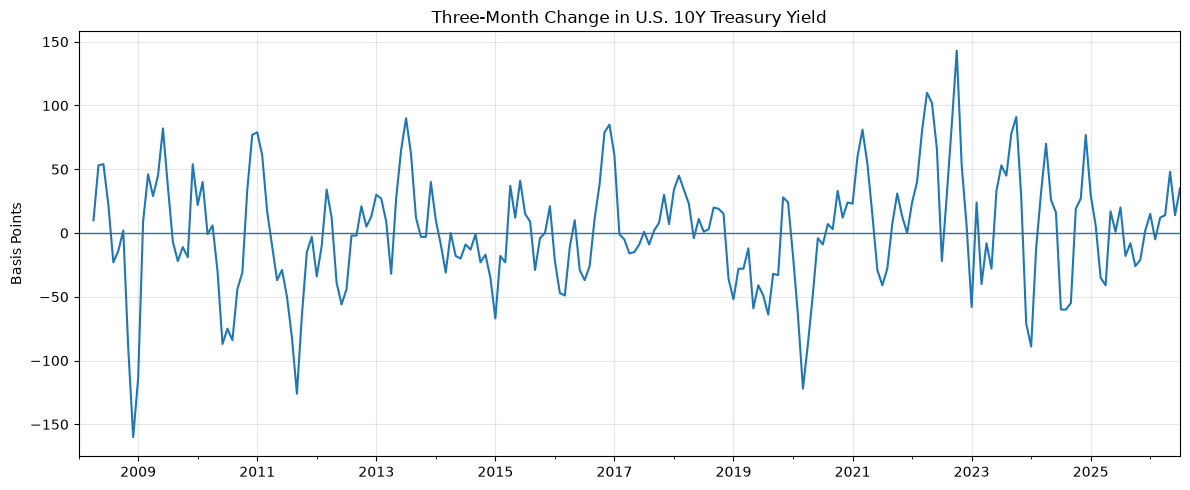

In [19]:
fig, ax = plt.subplots(
    figsize=(12, 5)
)

regime_data[
    "US10Y_3m_change_bps"
].plot(ax=ax)

ax.axhline(0, linewidth=1)

ax.set_title(
    "Three-Month Change in U.S. 10Y Treasury Yield"
)
ax.set_xlabel("")
ax.set_ylabel("Basis Points")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

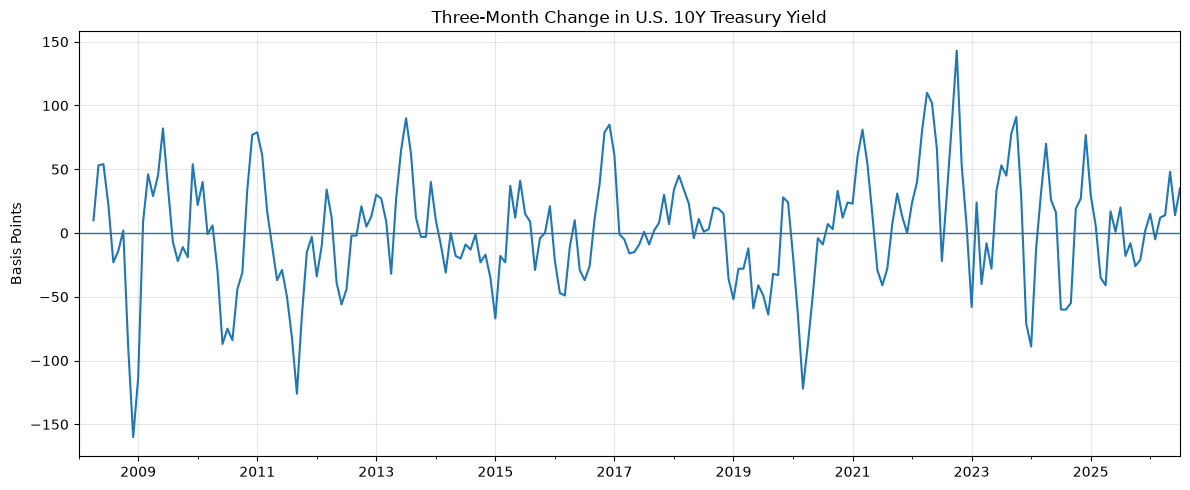

In [20]:
fig, ax = plt.subplots(
    figsize=(12, 5)
)

regime_data[
    "US10Y_3m_change_bps"
].plot(ax=ax)

ax.axhline(0, linewidth=1)

ax.set_title(
    "Three-Month Change in U.S. 10Y Treasury Yield"
)
ax.set_xlabel("")
ax.set_ylabel("Basis Points")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Signal Timing Convention

A regime observed at month-end \(t\) can only determine portfolio positioning for month \(t+1\).

Therefore:

**Month-end information at \(t\) → Portfolio weights for the following month**

The contemporaneous return in month \(t\) is never treated as the return generated by the regime observed at the end of that same month.

In [21]:
regime_data["Applied_Regime"] = (
    regime_data["Regime"].shift(1)
)

regime_data["Applied_Rate_State"] = (
    regime_data["Rate_State"].shift(1)
)

regime_data["Applied_Credit_State"] = (
    regime_data["Credit_State"].shift(1)
)

In [22]:
regime_data[
    [
        "Regime",
        "Applied_Regime",
        "SHY_ret",
        "IEF_ret",
        "TLT_ret",
        "LQD_ret",
        "HYG_ret",
    ]
].tail(8)

,Regime,Applied_Regime,SHY_ret,IEF_ret,TLT_ret,LQD_ret,HYG_ret
Date,,,,,,,
2025-12-31,Rising / Widening,Falling / Tightening,0.002947,-0.007612,-0.026586,-0.007375,0.004926
2026-01-31,Rising / Tightening,Rising / Widening,0.002053,-0.002288,-0.000345,0.003449,0.006077
2026-02-28,Falling / Widening,Rising / Tightening,0.005318,0.024700,0.046338,0.013780,-0.000012
2026-03-31,Rising / Widening,Falling / Widening,-0.004665,-0.023202,-0.042300,-0.020728,-0.009536
2026-04-30,Rising / Widening,Rising / Widening,0.001907,-0.001503,-0.008396,0.002819,0.015207
2026-05-31,Rising / Tightening,Rising / Widening,0.000766,-0.000190,0.005334,0.008624,0.004365
2026-06-30,Rising / Tightening,Rising / Tightening,0.000646,0.002512,0.011659,0.001129,0.000863
2026-07-31,Rising / Tightening,Rising / Tightening,0.001563,-0.013887,-0.044738,-0.022431,-0.001520


In [23]:
timing_check = pd.DataFrame({
    "Previous_Month_Regime":
        regime_data["Regime"].shift(1),
    "Applied_Regime":
        regime_data["Applied_Regime"],
})

valid_timing_rows = (
    timing_check.dropna()
)

assert (
    valid_timing_rows[
        "Previous_Month_Regime"
    ]
    ==
    valid_timing_rows[
        "Applied_Regime"
    ]
).all()

print(
    "Signal timing validation passed."
)

Signal timing validation passed.


In [24]:
REGIME_PATH = (
    PROCESSED_DIR
    / "fixed_income_regime_panel.csv"
)

regime_data.to_csv(
    REGIME_PATH
)

print(
    "Regime panel saved:"
)

print(REGIME_PATH)

print(
    "\nExists:",
    REGIME_PATH.exists(),
)

Regime panel saved:
c:\Users\minha\Desktop\global-fixed-income-strategy\data\processed\fixed_income_regime_panel.csv

Exists: True


In [25]:
primary_regimes = {
    "Falling / Tightening",
    "Falling / Widening",
    "Rising / Tightening",
    "Rising / Widening",
}

observed_regimes = set(
    regime_data["Regime"]
    .dropna()
    .unique()
)

assert primary_regimes.issubset(
    observed_regimes
), "One or more primary regimes were never observed."

assert (
    regime_data[
        "US10Y_3m_change_bps"
    ].isna().sum()
    == 3
)

assert (
    regime_data[
        "BAA10Y_3m_change_bps"
    ].isna().sum()
    == 3
)

print("=" * 60)
print(
    "STEP 3 — RATE/CREDIT REGIME CONSTRUCTION COMPLETE"
)
print("=" * 60)

print(
    f"\nUsable regime observations: "
    f"{regime_data['Regime'].notna().sum()}"
)

print("\nRegime distribution:")
print(regime_data["Regime"].value_counts())

print(
    "\nSignal timing:"
    "\nMonth-end regime at t "
    "→ portfolio month t+1"
)

print(
    "\nNo portfolio weights "
    "or performance optimization applied."
)

STEP 3 — RATE/CREDIT REGIME CONSTRUCTION COMPLETE

Usable regime observations: 220

Regime distribution:
Regime
Rising / Tightening     83
Falling / Widening      57
Falling / Tightening    46
Rising / Widening       30
Stable / Mixed           4
Name: count, dtype: int64

Signal timing:
Month-end regime at t → portfolio month t+1

No portfolio weights or performance optimization applied.


## Step 3 Conclusion

The pre-specified rate and credit signals have been constructed using three-month changes in the U.S. 10-year Treasury yield and Baa corporate credit spread.

These signals generate four primary market regimes:

1. Falling / Tightening
2. Falling / Widening
3. Rising / Tightening
4. Rising / Widening

The regime observed at each month-end is shifted forward and can only affect the following month's portfolio positioning.

No ETF performance was used to define the signal horizon, threshold, or regime classification.

The next stage translates these market regimes into economically motivated duration and credit exposures before any strategy backtest is evaluated.